In [20]:
##### Creates maps of capital and labor intensities (national & sub-national)

import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

In [21]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# Import sub-national data

sub_capital = pd.read_csv(f"{cd}/Data/Clean/Intensities/subnational_capital_intensity.csv")
sub_labor = pd.read_csv(f"{cd}/Data/Clean/Intensities/subnational_labor_intensity.csv")

sub_geo_capital = gpd.read_file(f"{cd}/Data/Clean/Capital_stock/subnational_capital_stock_final_GEO.shp")
sub_geo_labor = gpd.read_file(f"{cd}/Data/Clean/Labor/subnational_labor_final_geo.shp")

# Import country data

country_intensities = pd.read_csv(f"{cd}/Data/Clean/Intensities/country_intensities.csv")
country_shp = gpd.read_file("/Users/carinamanitius/Documents/Data/Admin_Boundaries/gadm_410-levels.gpkg", layer='ADM_0')

country_codes = pd.read_csv(f"{cd}/Data/Correspondence_tables/country_names.csv", encoding="cp1252")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures"

In [22]:
### Data prep

# align crs

crs = "ESRI:54042"

sub_geo_capital = sub_geo_capital.to_crs(crs)
sub_geo_labor = sub_geo_labor.to_crs(crs)
country_shp = country_shp.to_crs(crs)

# prep country shp 
country_shp = country_shp.merge(country_codes, left_on='GID_0', right_on='SHP_code', how='inner')

# join data to shape
sub_geo_capital = sub_geo_capital.merge(sub_capital, on='PROJ_ID', how='outer')
sub_geo_labor = sub_geo_labor.merge(sub_labor, on='PROJ_ID', how='outer')

country_shp = country_shp.merge(country_intensities, on='ISO3', how='outer')

In [24]:
sub_geo_capital

Index(['ISO3', 'GEO_ID', 'GEO_ID_NM', 'value', 'unit', 'geometry',
       'GEO_ID_NAME', 'ag_capital_stock_USD_nominal', 'total_production_USD',
       'capital_intensity_USD_per_USD'],
      dtype='object')

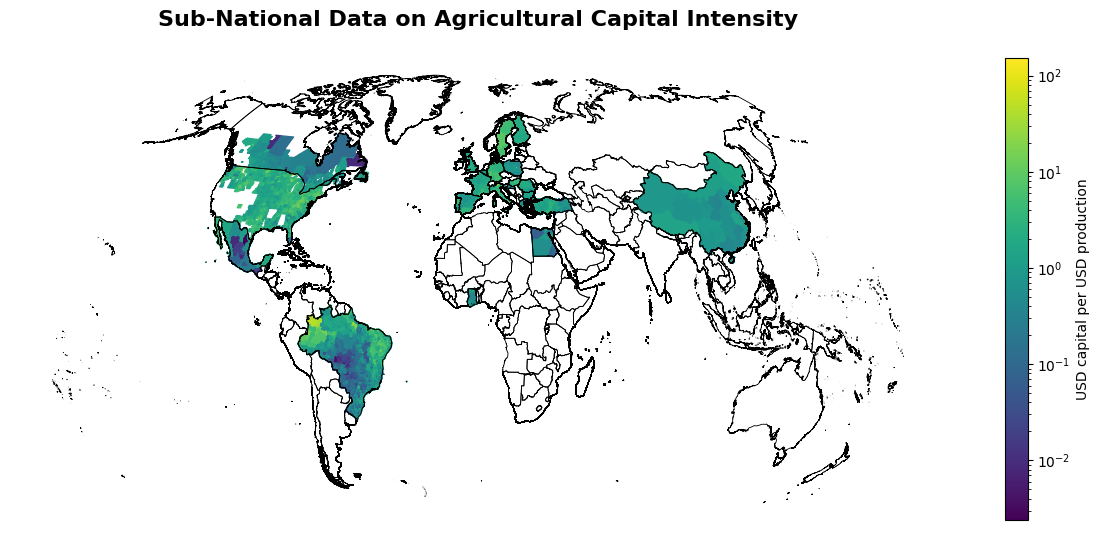

In [28]:
##### Plot sub-national capital intensity 

# Remove zero's
sub_geo_capital_pos = sub_geo_capital[sub_geo_capital['value'] > 0].copy()
sub_geo_capital_zero = sub_geo_capital[~(sub_geo_capital['value'] > 0)].copy()

### Plot
fig, ax = plt.subplots(figsize=(12,8))

# Plot positive values
sub_geo_capital_pos.plot(
    column='capital_intensity_USD_per_USD',
    cmap='viridis',
    norm=LogNorm(),   
    edgecolor='face',
    ax=ax,
    legend=True,
    legend_kwds={
        'label': "USD capital per USD production",
        'shrink': 0.6,
        'orientation': 'vertical'
    },
    zorder=2
)

# Add country boundaries
country_shp.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.6,
    zorder=10
)

# Aesthetics
ax.set_axis_off()  
ax.set_title("Sub-National Data on Agricultural Capital Intensity", fontsize=16, weight='bold', pad=20)
plt.tight_layout()

plt.show()

fig.savefig(f"{fd}/subnational_capital_intensity.png", dpi=300, bbox_inches='tight')